In [1]:
import dbof.dataset_creation.zarr_dataset as zarr_dataset
import dbof.io.filesystems as filesystems

In [9]:
from dask.distributed import Client
import numpy as np

In [4]:
# follow link for a progress bar in following steps
client = Client(n_workers=8)

port = client.scheduler_info()["services"]["dashboard"]
# For nrp link is :
#https://jupyterhub-west.nrp-nautilus.io/hub/user-redirect/proxy/{port}/status
print(f"url : https://jupyterhub-west.nrp-nautilus.io/hub/user-redirect/proxy/{port}/status")

/home/jovyan/conda_envs/torch_env/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 42903 instead
  warnings.warn(


url : https://jupyterhub-west.nrp-nautilus.io/hub/user-redirect/proxy/42903/status


In [5]:
bucket = "dbof" #data_cfg["bucket"]
folder = "native_grid_dbof_training_data"
s3_endpoint = "https://s3-west.nrp-nautilus.io"
feature_channels = ['Eta', 'Salt', 'Theta', 'U', 'V', 'W', 'relative_vorticity', 'log_gradb']
run_id = "big_run_00"

fs, fs_synch = filesystems.create_s3_filesystems(s3_endpoint)

reader = zarr_dataset.ZarrDatasetReader(
    bucket=bucket,
    folder=folder,
    run_id=run_id,
    dataset_name="dataset_creation.zarr",
    fs=fs
)

In [6]:
images_da, ids_da, valid_mask_da = reader.full_dataset_as_dask()

In [7]:
def chunk_aware_subsample(da, num_sample_chunks, subsample_per_chunk):
    chunk = 1020
    rng = np.random.default_rng()
    
    n = da.shape[0]
    n_chunks = (n + chunk - 1) // chunk
    
    
    sample_chunks = rng.choice(n_chunks, size=num_sample_chunks, replace=False)
    
    # within each chosen chunk, pick r indices
    
    idx = []
    for c in sample_chunks:
        start = c * chunk
        stop = min((c + 1) * chunk, n)
        idx.append(rng.integers(start, stop, size=subsample_per_chunk))
    
    idx = np.sort(np.concatenate(idx))
    return idx

In [10]:
subset = True 


subsample_per_chunk = 300
num_sample_chunks = 30
if subset:
    N = len(images_da)
    subset_idxs = chunk_aware_subsample(images_da, num_sample_chunks, subsample_per_chunk)
    images_da = images_da[subset_idxs]
    ids_da = ids_da[subset_idxs]

In [11]:
images_np = images_da.compute() 

In [14]:
theta = images_np[:, 2]   # (N, 64, 64)

print("Any NaN:", np.isnan(theta).any())
print("Any +inf:", np.isposinf(theta).any())
print("Any -inf:", np.isneginf(theta).any())

print("Total NaNs:", np.isnan(theta).sum())
print("Total infs:", np.isinf(theta).sum())

# Boolean mask: True if patch has any NaN
bad_patch_mask = np.isnan(theta).reshape(theta.shape[0], -1).any(axis=1)

num_bad = bad_patch_mask.sum()
print("Number of patches containing NaN:", num_bad)

bad_indices = np.where(bad_patch_mask)[0]
print("First 10 bad patch indices:", bad_indices[:10])

N = images_np.shape[0]

keep_mask = np.ones(N, dtype=bool)
keep_mask[bad_indices] = False

images_clean_np = images_np[keep_mask]

print("Old shape:", images_np.shape)
print("New shape:", images_clean_np.shape)

vort = images_clean_np[:, 6]   # (N, 64, 64)

print("Any NaN:", np.isnan(vort).any())
print("Any +inf:", np.isposinf(vort).any())
print("Any -inf:", np.isneginf(vort).any())

print("Total NaNs:", np.isnan(vort).sum())
print("Total infs:", np.isinf(vort).sum())

# Boolean mask: True if patch has any NaN
bad_patch_mask = np.isnan(vort).reshape(vort.shape[0], -1).any(axis=1)

num_bad = bad_patch_mask.sum()
print("Number of patches containing NaN:", num_bad)

bad_indices = np.where(bad_patch_mask)[0]
print("First 10 bad patch indices:", bad_indices[:10])

#Filter out cutouts containing nan gradients 
N = images_clean_np.shape[0]

keep_mask = np.ones(N, dtype=bool)
keep_mask[bad_indices] = False

images_clean_np = images_clean_np[keep_mask]

Any NaN: True
Any +inf: False
Any -inf: False
Total NaNs: 506
Total infs: 0
Number of patches containing NaN: 18
First 10 bad patch indices: [3250 3627 3628 6640 6641 6642 6705 6706 6782 6783]
Old shape: (9000, 8, 64, 64)
New shape: (8982, 8, 64, 64)


In [31]:
images_clean_np.shape

(8981, 8, 64, 64)

In [32]:
B = images_clean_np[:,7]
B.shape

(8981, 64, 64)

In [77]:
eta_theta_salt = images_clean_np[:,0:3]

In [78]:
eta_theta_salt.shape

(8981, 3, 64, 64)

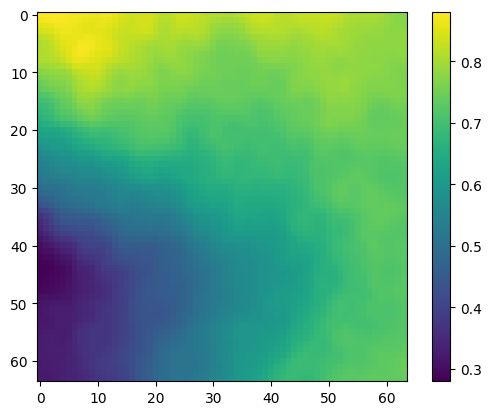

In [82]:
import matplotlib.pyplot as plt

eta = eta_theta_salt[0][0]
plt.imshow(eta)
plt.colorbar()

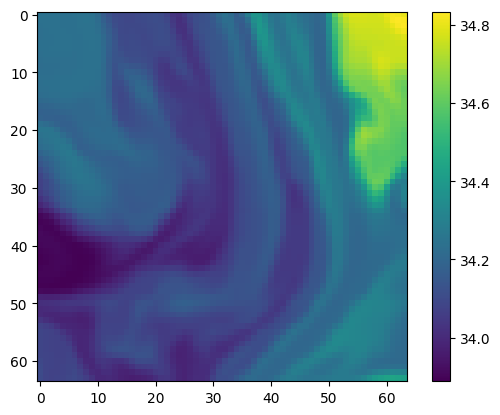

In [83]:
theta = eta_theta_salt[0][1]
plt.imshow(theta)
plt.colorbar()

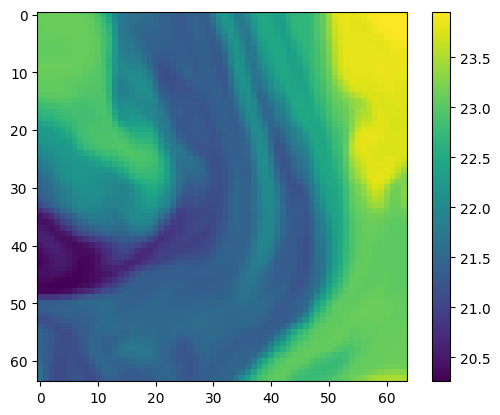

In [84]:
import matplotlib.pyplot as plt
salt = eta_theta_salt[0][2]
plt.imshow(salt)
plt.colorbar()

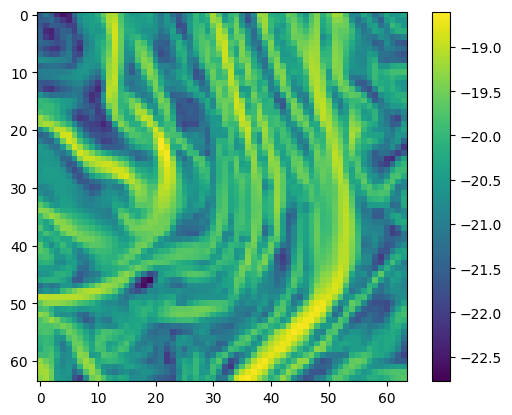

In [85]:
b = B[0]
plt.imshow(b)
plt.colorbar()

In [86]:
B.shape

(8981, 64, 64)

In [87]:
def make_regime_labels(b, n_classes=3, eps=1e-12):
    """
    grad_b2: array of shape [N, 1, H, W] or [N, H, W]
    Returns:
        patch_stat: [N] median log(grad_b2)
        labels:     [N] integer class labels
        bins:       quantile bin edges
    """

    # one scalar per patch
    patch_stat = np.mean(b, axis=(1, 2))   # [N]

    # quantile bins for balanced classes
    bins = np.quantile(patch_stat, np.linspace(0, 1, n_classes + 1))

    # avoid edge issue at the max
    bins[-1] += 1e-9

    labels = np.digitize(patch_stat, bins[1:-1], right=False)

    return patch_stat, labels.astype(np.int64), bins

In [88]:
patch_stat, labels, bins = make_regime_labels(B, n_classes=3)

print("patch_stat shape:", patch_stat.shape)
print("labels shape:", labels.shape)
print("class counts:", np.bincount(labels))
print("bins:", bins)

patch_stat shape: (8981,)
labels shape: (8981,)
class counts: [2994 2993 2994]
bins: [-2.27090454e+01 -2.09158319e+01 -2.03894030e+01  1.00000000e-09]


In [89]:
labels[0:10]

array([2, 2, 1, 1, 0, 0, 1, 2, 2, 2])

In [92]:
def plot_ocean_samples(X, B, labels, n_samples=5):
    idx = [0,1,2,4,14]

    fig, axes = plt.subplots(n_samples, 5, figsize=(12, 3*n_samples))

    for r, i in enumerate(idx):
        eta = X[i, 0]
        theta  = X[i, 1]
        salt = X[i,2]
        grad  = B[i]

        def norm(x):
            return x #(x - np.nanmin(x)) / (np.nanmax(x) - np.nanmin(x) + 1e-8)

        im0 = axes[r,0].imshow(norm(eta), cmap="viridis", origin="lower")
        axes[r,0].set_title("eta")
        fig.colorbar(im0, ax=axes[r,0])

        im1 = axes[r,1].imshow(norm(theta), cmap="viridis", origin="lower")
        axes[r,1].set_title("theta")
        fig.colorbar(im1, ax=axes[r,1])

        im2 = axes[r,2].imshow(norm(salt), cmap="viridis", origin="lower")
        axes[r,2].set_title("salt")
        fig.colorbar(im1, ax=axes[r,2])

        im3 = axes[r,3].imshow(norm(grad), cmap="magma", origin="lower")
        axes[r,3].set_title("log(grad(b²))")
        fig.colorbar(im2, ax=axes[r,3])

        axes[r,4].text(
            0.5, 0.5, f"class {labels[i]}",
            ha="center", va="center", fontsize=14
        )
        axes[r,3].set_title("label")
        axes[r,3].set_xticks([])
        axes[r,3].set_yticks([])

        for c in range(3):
            axes[r,c].set_xticks([])
            axes[r,c].set_yticks([])

    plt.tight_layout()
    plt.show()

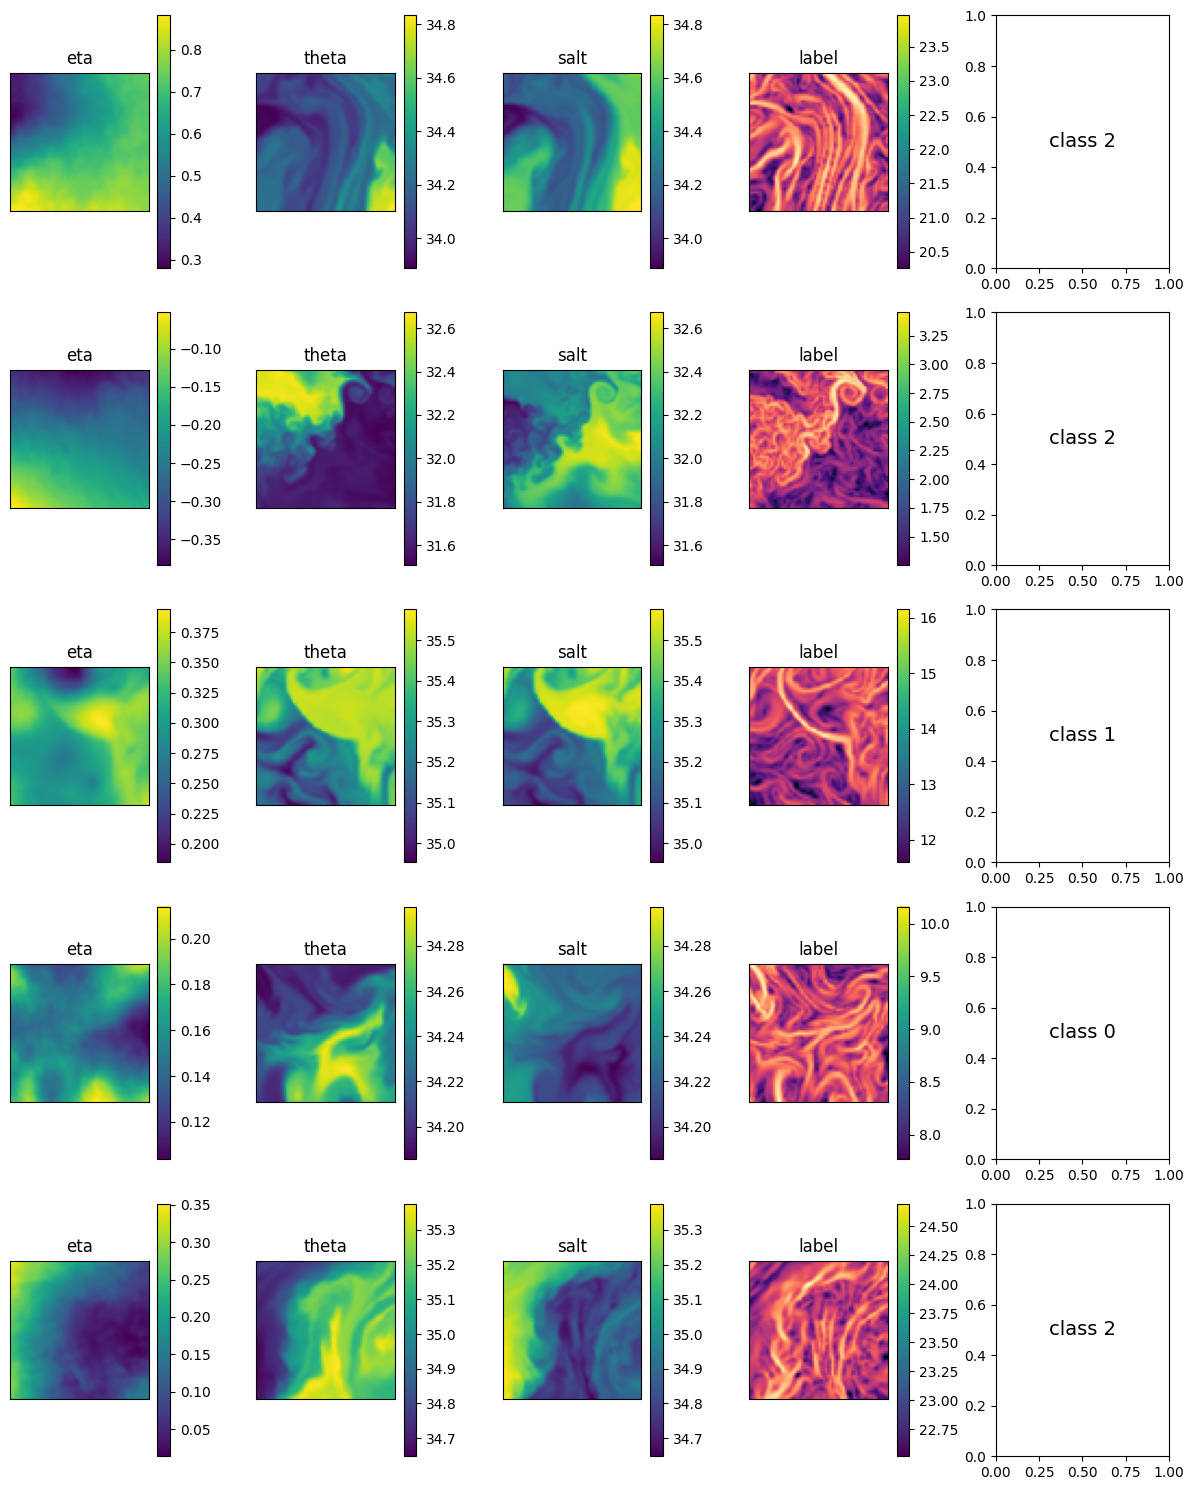

In [93]:
plot_ocean_samples(eta_theta_salt, B, labels, n_samples=5)

In [94]:
import numpy as np

counts = np.bincount(labels)

print("class counts:", counts)
print("total samples:", counts.sum())

class counts: [2994 2993 2994]
total samples: 8981


In [95]:
from torch.utils.data import Dataset, DataLoader

class OceanPatchDataset(Dataset):
    def __init__(self, X, labels):
        """
        X: array/tensor of shape [N, C, H, W]
        labels: array/tensor of shape [N]
        """
        self.X = torch.as_tensor(X, dtype=torch.float32)
        self.labels = torch.as_tensor(labels, dtype=torch.long)
        
        if len(self.X) != len(self.labels):
            raise ValueError(f"X and labels must have same length, got {len(self.X)} and {len(self.labels)}")

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "image": self.X[idx],
            "label": self.labels[idx],
        }


def make_ocean_dataloaders(X_train, y_train, X_val, y_val, batch_size=64, num_workers=0):
    train_ds = OceanPatchDataset(X_train, y_train)
    val_ds = OceanPatchDataset(X_val, y_val)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )

    return train_loader, val_loader



In [96]:
from sklearn.model_selection import train_test_split
import torch 

X_train, X_val, y_train, y_val = train_test_split(
    eta_theta_salt, labels, test_size=0.2, random_state=42, stratify=labels
)

ocean_loader, ocean_loader_val = make_ocean_dataloaders(
    X_train, y_train, X_val, y_val, batch_size=64
)

torch.Size([64, 3, 64, 64])
shape: torch.Size([64, 3, 64, 64])
dtype: torch.float32
device: cpu
min: -1.847279667854309
max: 36.44630813598633
nan count: 0
inf count: 0


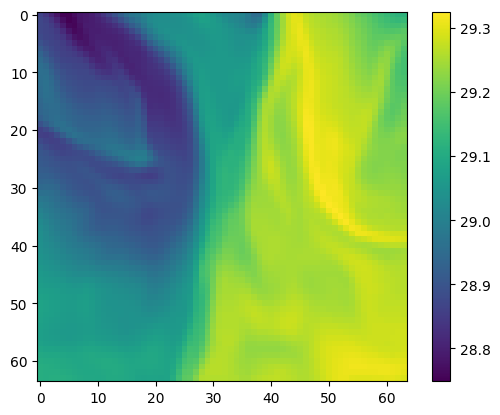

In [98]:
for batch in ocean_loader_val:

    images = batch["image"]
    labels = batch["label"]
    print(images.shape)

    img = images[0][2]

    plt.imshow(img)
    plt.colorbar()

    images = batch["image"]
    print("shape:", images.shape)
    print("dtype:", images.dtype)
    print("device:", images.device)
    print("min:", images.min().item())
    print("max:", images.max().item())
    print("nan count:", torch.isnan(images).sum().item())
    print("inf count:", torch.isinf(images).sum().item())
    break